## Setup

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import numpy as np
from sklearn.metrics import mean_squared_error

In [7]:
df = pd.read_csv('./data/concrete_data.csv')
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [8]:
df.isna().sum()

Cement                           0
Blast Furnace Slag               0
Fly Ash                          0
Water                            0
Superplasticizer                 0
Coarse Aggregate                 0
Fine Aggregate                   0
Age                              0
Concrete compressive strength    0
dtype: int64

## EDA

In [9]:
df['water-cement ratio'] = df['Water'] / df['Cement']

df['binder'] = df['Cement'] + df['Blast Furnace Slag'] + df['Fly Ash']

df['fine-course ratio'] = df['Fine Aggregate'] / df['Coarse Aggregate']

In [10]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength,water-cement ratio,binder,fine-course ratio
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99,0.300000,540.0,0.650000
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89,0.300000,540.0,0.640758
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27,0.685714,475.0,0.637339
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05,0.685714,475.0,0.637339
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30,0.966767,331.0,0.843724


#### Strength v Age

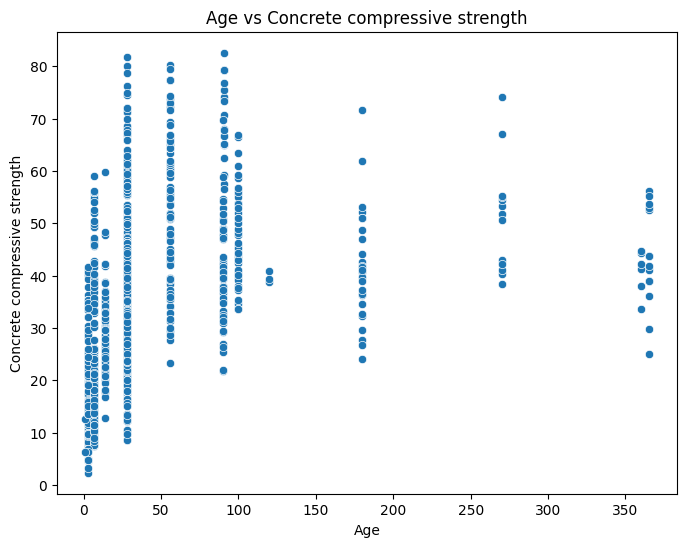

In [22]:
plt.figure(figsize=(8, 6))
ax = sns.scatterplot(data=df, x='Age', y='Concrete compressive strength')
ax.set_title('Age vs Concrete compressive strength')
plt.show()

From graph we can infer that, there is some non-linear relation between age and strength. till age of 100  it varies and the function saturates post age=100.

#### Strength v W/C Ratio

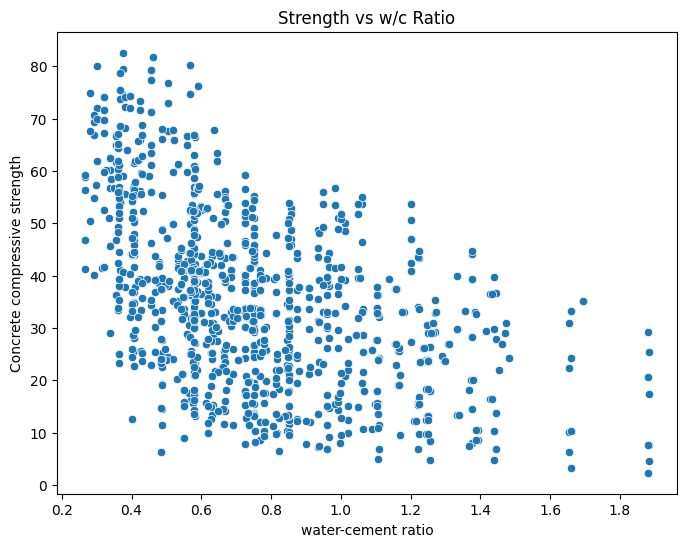

In [23]:
plt.figure(figsize=(8, 6))
ax = sns.scatterplot(data=df, x='water-cement ratio', y='Concrete compressive strength')
ax.set_title('Strength vs w/c Ratio')
plt.show()

On the whole the mean at every w/c ratio looks to be decreasing with the ratio. Hence, we can say that more cement means better strength.

There is a non-linear relation here too.

#### Heatmap

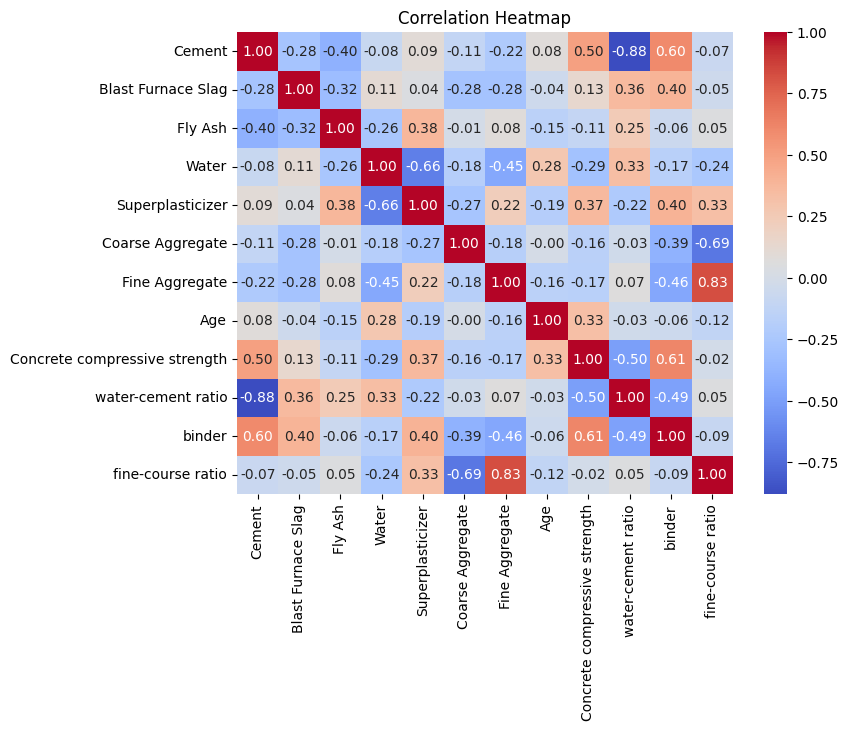

In [24]:
plt.figure(figsize=(8, 6))
# cols = [
#     'Concrete compressive strength', 'Age', 'water-cement ratio', 'binder', 'Superplasticizer']
cols = df.columns
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

To our target value (strength) the following seem the most relevant:
- Cement seems to have a high correlation of 0.5
- Cement-water ratio has high negative corr, but its due to cement
- binder seems to have quite good correlation with the strength
- Superplasticizer (not present in any engineered feature) has good correlation with the strength
- Age happens to have decent correlation as well.

## Part B: MLR

#### B1

In [34]:
original_predictors = [
    'Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 
    'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age'
]
target = 'Concrete compressive strength'

X = df[original_predictors]
y = df[target]

# Split the data 80/20 with a random seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

#### B2

In [35]:
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# Fit the OLS (Ordinary Least Squares) model on the training data
model = sm.OLS(y_train, X_train_sm).fit()

# Print the full coefficient table, which includes R^2, Adj R^2, standard errors, and p-values
print(model.summary())

                                  OLS Regression Results                                 
Dep. Variable:     Concrete compressive strength   R-squared:                       0.609
Model:                                       OLS   Adj. R-squared:                  0.605
Method:                            Least Squares   F-statistic:                     158.7
Date:                           Wed, 08 Apr 2026   Prob (F-statistic):          1.56e-160
Time:                                   12:00:25   Log-Likelihood:                -3106.7
No. Observations:                            824   AIC:                             6231.
Df Residuals:                                815   BIC:                             6274.
Df Model:                                      8                                         
Covariance Type:                       nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-------------

In [36]:
# Calculate Test-set RMSE
y_pred = model.predict(X_test_sm)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"\nTest-set RMSE: {test_rmse:.4f}")


Test-set RMSE: 9.7944


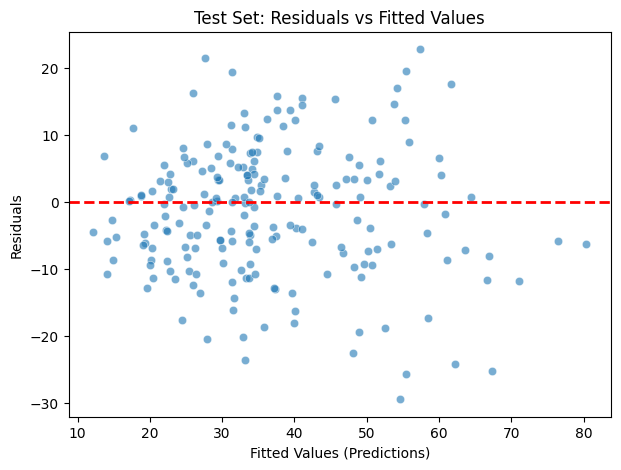

In [37]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))
# Plotting Residuals vs Fitted values
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Fitted Values (Predictions)')
plt.ylabel('Residuals')
plt.title('Test Set: Residuals vs Fitted Values')
plt.show()

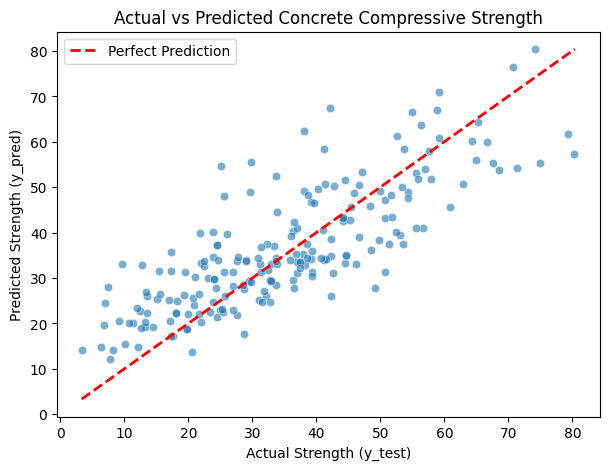

In [38]:
plt.figure(figsize=(7, 5))

# Scatter plot of actual vs predicted values
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)

# Add a 45-degree reference line for perfect predictions
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Strength (y_test)')
plt.ylabel('Predicted Strength (y_pred)')
plt.title('Actual vs Predicted Concrete Compressive Strength')
plt.legend()
plt.show()

#### B3

In [43]:
predictor = 'Superplasticizer'
p_value = model.pvalues[predictor]
conf_int = model.conf_int(alpha=0.05).loc[predictor]
coef = model.params[predictor]

print(f"Predictor: {predictor}")
print(f"Coefficient: {coef:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"95% Confidence Interval: [{conf_int[0]:.4f}, {conf_int[1]:.4f}]")

Predictor: Superplasticizer
Coefficient: 0.2552
P-value: 0.0215
95% Confidence Interval: [0.0377, 0.4728]
